# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [1]:
ПІБ = 'Кшик Олена Андріївна'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'      # напр. 'КН-31'
ВАРІАНТ = 9     # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [2]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 9 · Кшик Олена Андріївна, ШІ-34, «Астро-ТВ»
Підприємство «Астро-ТВ» виготовляє телевізори. Одиниця виміру плану: шт./день.

                       Astro  Cosmo  Nova  Vega  ЗАПАС
Конвеєр A, год             5      2     1     2   1147
Конвеєр Б, год             5      0     1     3   1199
Цех кінескопів, год        5      4     6     4   1280
Цех корпусів, год          4      1     1     5    404
Ділянка збирання, год      6      0     3     0   1170

                    Astro  Cosmo  Nova  Vega
Прибуток з одиниці     58     39    54    16

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Цех кінескопів, год
  ціна:   6.1 за одиницю
  обсяг:  до 672 одиниць


In [3]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення: x1, x2, x3, x4 (телевізори, од. вимірювання - шт.)

Цільова функція: 58·x1 + 39·x2 + 54·x3 + 16·x4 -> max

Обмеження: 

5·x1 + 2·x2 +   x3 + 2·x4 <= 1147

5·x1 +          x3 + 3·x4 <= 1199

5·x1 + 4·x2 + 6·x3 + 4·x4 <= 1280

4·x1 +   x2 +   x3 + 5·x4 <= 404

6·x1 +        3·x3 +      <= 1170

Невід'ємність:

x1 >= 0, x2 >= 0, x3 >= 0, x4 >= 0

### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?


**Відповідь 1.2:** Запас ресурсу це параметр, оскільки ми не можемо змінювати(збільшувати) його запас. Якби підприємство могло докупити ресурс, то ці значення стали б ще невідомими у рівнянні. І якщо ціна продажу продукту з цього ресурсу є вищою за ціну закупівлі, то розв'язок може прямувати до нескінченності.

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [4]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [30.54545455, 281.8181818, 0, 0]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 12762.54545             # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [30.54545455, 281.8181818, 0, 0] | прибуток 12762.54545


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [5]:
r = linprog(-c, A_ub=A, b_ub=b, bounds=[(0, None)] * len(c), method='highs')

план = r.x
прибуток = -r.fun

**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [6]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Конвеєр A, год  Сумарне споживання | 716,3636364 | 0 | 1147 | 1E+30 | 430,6363636 |
| Конвеєр Б, год  Сумарне споживання | 152,7272727 | 0 | 1199 | 1E+30 | 1046,272727 |
| Цех кінескопів, год Сумарне споживання | 1280 | 8,909090909 | 1280 | 336 | 775 |
| Цех корпусів, год  Сумарне споживання | 404 | 3,363636364 | 404 | 452,25 | 84 |
| Ділянка збирання, год   Сумарне споживання | 183,2727273 | 0 | 1170 | 1E+30 | 986,7272727 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?** Ресурси в дефіциті це ті в яких тіньова ціна > 0, це означає що якщо докупити 1 одиницю цього ресурсу, то ми отримаємо прибуток який дорівнюй цій ціні. Ресурси в надлишку це ті в яких тіньова ціна 0, оскільки їх і так лишилось забагато то закупівля нових не принесе прибутку.


### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Виготовлена кількість Astro | 30,54545455 | 0 | 58 | 15,5 | 9,25 |
| Виготовлена кількість Cosmo | 281,8181818 | 0 | 39 | 7,4 | 1,631578947 |
| Виготовлена кількість Nova | 0 | -2,818181818 | 54 | 2,818181818 | 1E+30 |
| Виготовлена кількість Vega | 0 | -36,45454545 | 16 | 36,45454545 | 1E+30 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?
Товари Nova і Vega не увійшли в план, оскільки їх не вигідно виробляти. Щоб Nova увійшов в план, треба щоб його собівартість знизилась на 2.8182 одиниць, або щоб ціна зросла на стільки ж. Те саме стосується і Vega (36,4545). Ці числа це зведена вартість, показник скільки ми втрачаємо якщо почнемо виробляти ці товари і заодно показник наскільки треба збільшити їх ціну.


---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [ ]:
sh_prices = -r.ineqlin.marginals
k = int(np.argmax(sh_prices))              
sh_price_excel = 8.909090909   

b1 = b.copy()
b1[k] += 1
r1 = linprog(-c, A_ub=A, b_ub=b1, bounds=[(0, None)] * len(c), method='highs')
приріст = -r1.fun - прибуток

print('Найдорожчий ресурс:        %s (тіньова ціна %.4f)' % (ресурси[k], sh_prices[k]))
print('Приріст прибутку:          %.4f' % приріст)
print('Тіньова ціна зі звіту:     %.4f' % sh_price_excel)
print('Збігаються:', np.isclose(приріст, sh_price_excel, atol=1e-4))

Найдорожчий ресурс:        Цех кінескопів, год (тіньова ціна 8.9091)
Прибуток, базовий запас:   12762.5455
Прибуток, запас +1:        12771.4545
Приріст прибутку:          8.9091
Тіньова ціна зі звіту:     8.9091
Збігаються: True


**Відповідь 5.1:** найдорожчий за тіньовою ціною ресурс — «Цех кінескопів, год».
Коли його запас збільшити з 1280 до 1281 год, прибуток зростає з 12762.5455 до 12771.4545,
тобто приріст прибутку = 8.9091. Тіньова ціна зі звіту = 8.9091 (8,909090909).
Числа збігаються: кожна додаткова година цеху кінескопів дає 8.91 грошових одиниць прибутку.

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

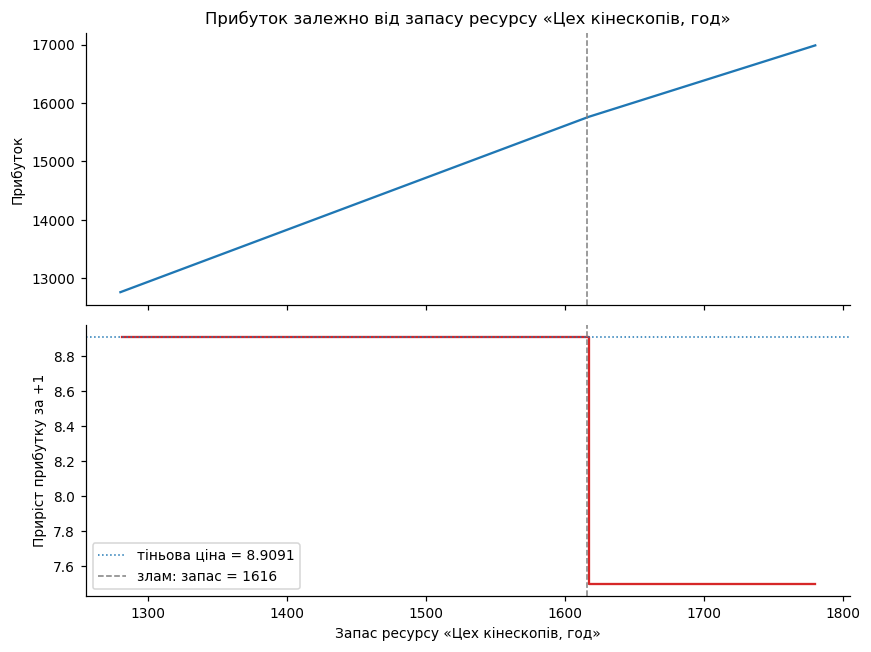

In [21]:
ALLOWED_INCREASE_EXCEL = 336          

stocks = np.arange(b[k], b[k] + 501)       
profits = []
for v in stocks:
    b_new = b.copy()
    b_new[k] = v
    res_v = linprog(-c, A_ub=A, b_ub=b_new, bounds=[(0, None)] * len(c), method='highs')
    profits.append(-res_v.fun)
profits = np.array(profits)
profit_slope = np.diff(profits)                   

break_idx = int(np.argmax(~np.isclose(profit_slope, sh_prices[k], atol=1e-6)))
limit_stock = stocks[break_idx]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax1.plot(stocks, profits, color='tab:blue')
ax1.axvline(limit_stock, color='grey', ls='--', lw=1)
ax1.set_ylabel('Прибуток')
ax1.set_title('Прибуток залежно від запасу ресурсу «%s»' % ресурси[k])

ax2.step(stocks[1:], profit_slope, where='post', color='tab:red')
ax2.axhline(sh_prices[k], color='tab:blue', ls=':', lw=1,
            label='тіньова ціна = %.4f' % sh_prices[k])
ax2.axvline(limit_stock, color='grey', ls='--', lw=1, label='злам: запас = %d' % limit_stock)
ax2.set_xlabel('Запас ресурсу «%s»' % ресурси[k])
ax2.set_ylabel('Приріст прибутку за +1')
ax2.legend(loc='lower left')
plt.tight_layout()
plt.show()

**Відповідь 5.2:** запас цеху кінескопів можна збільшити на 336 год (з 1280 до 1616),
і весь цей час кожна додаткова година дає рівно 8.9091 прибутку (горизонтальна ділянка
на нижньому графіку). Після 1616 год нахил падає до 7.5. Тому що змінюється оптимальний базис, і тіньова ціна стає іншою.
Знайдена межа збігається з допустимим збільшенням зі звіту Excel (336).

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [9]:
# ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
#   ресурс: Цех кінескопів, год
#   ціна:   6.1 за одиницю
#   обсяг:  до 672 одиниць

offer_res = V['ресурс_пропозиції']
offer_price = V['ціна_пропозиції']
offer_volume = V['обсяг_пропозиції']

def solve_with_stock(stock):
    b_new = b.copy()
    b_new[offer_res] = stock
    res = linprog(-c, A_ub=A, b_ub=b_new, bounds=[(0, None)] * len(c), method='highs')
    return -res.fun, res.x, -res.ineqlin.marginals

base_profit, base_plan, base_shadow = solve_with_stock(b[offer_res])
print('Resource: %s' % ресурси[offer_res])
print('Shadow price: %.4f | offer price: %.1f' % (base_shadow[offer_res], offer_price))

volumes = np.arange(0, offer_volume + 1)
extra_profit = np.array([solve_with_stock(b[offer_res] + q)[0] for q in volumes]) - base_profit
net_gain = extra_profit - offer_price * volumes
best_q = int(volumes[np.argmax(net_gain)])

slope = np.diff(extra_profit)
breaks = np.where(~np.isclose(slope[1:], slope[:-1], atol=1e-6))[0] + 1
print('\nMarginal value of one extra unit, by purchase segment:')
start = 0
for end in list(breaks) + [len(slope)]:
    print('  +%4d .. +%4d units: %.4f per unit (%s price %.1f)'
          % (start, end, slope[start],
             'above' if slope[start] > offer_price else 'below', offer_price))
    start = end

new_profit, new_plan, new_shadow = solve_with_stock(b[offer_res] + best_q)
direct_gain = new_profit - base_profit - offer_price * best_q

print('\nRecommended purchase: %d units, cost %.1f' % (best_q, offer_price * best_q))
print('Direct solve: profit %.4f -> %.4f, net gain after paying supplier: %.4f'
      % (base_profit, new_profit, direct_gain))
print('New plan:', {name: round(float(x), 4) for name, x in zip(вироби, new_plan)})


Resource: Цех кінескопів, год
Shadow price: 8.9091 | offer price: 6.1

Marginal value of one extra unit, by purchase segment:
  +   0 .. + 336 units: 8.9091 per unit (above price 6.1)
  + 336 .. + 672 units: 7.5000 per unit (above price 6.1)

Recommended purchase: 672 units, cost 4099.2
Direct solve: profit 12762.5455 -> 18276.0000, net gain after paying supplier: 1414.2545
New plan: {'Astro': 0.0, 'Cosmo': 236.0, 'Nova': 168.0, 'Vega': 0.0}


**Відповідь 6.1:**

* **Брати чи ні і чому:** брати. Тіньова ціна цеху кінескопів - 8.9091 за годину, а постачальник просить 6.1. Кожна куплена година приносить більше прибутку, ніж коштує: +2.81 на годину.
* **Скільки одиниць має сенс купити і чому не більше:** усі 672 год. Звіт гарантує тіньову ціну 8.9091 лише для перших 336 год (допустиме збільшення). Але експеримент показує, що після 1616 год ціна кожної години падає до 7.5. 7.5 > 6.1, отже купувати вигідно на всьому обсязі пропозиції.
* **Очікуваний виграш:** за звітом Excel можна впевнено порахувати тільки перші 336 год:
336 · (8.9091 − 6.1) = 943.85. З урахуванням другого відрізка:
943.85 + 336 · (7.5 − 6.1) = 943.85 + 470.40 = 1414.25.
* **Перевірка прямим розв'язанням дала:** із запасом 1280 + 672 = 1952 год прибуток зростає з 12762.55 до 18276.00 (+5513.45). Мінус оплата постачальнику 672 · 6.1 = 4099.20, чистий виграш 1414.25, збігається з розрахунком. 

---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [10]:
eps = 1e-6
base_plan = np.array(план, float)
usage = A @ base_plan                      # сумарне споживання кожного ресурсу
slack = b - usage                          # залишок ресурсу

nonzero_mask = base_plan > eps
binding_mask = np.abs(slack) < eps

ненульових = int(nonzero_mask.sum())
звязних = int(binding_mask.sum())

print(pd.DataFrame({'Випуск': base_plan.round(4)}, index=вироби).to_string())
print()
print(pd.DataFrame({'Споживання': usage.round(4), 'Запас': b, 'Залишок': slack.round(4),
                    'Тіньова ціна': sh_prices.round(4), 'Зв’язне': binding_mask},
                   index=ресурси).to_string())
print()
print('Ненульові вироби:', [p for p, m in zip(вироби, nonzero_mask) if m])
print('Зв’язні обмеження:', [res for res, m in zip(ресурси, binding_mask) if m])


         Випуск
Astro   30.5455
Cosmo  281.8182
Nova     0.0000
Vega     0.0000

                       Споживання   Запас    Залишок  Тіньова ціна  Зв’язне
Конвеєр A, год           716.3636  1147.0   430.6364        0.0000    False
Конвеєр Б, год           152.7273  1199.0  1046.2727        0.0000    False
Цех кінескопів, год     1280.0000  1280.0     0.0000        8.9091     True
Цех корпусів, год        404.0000   404.0     0.0000        3.3636     True
Ділянка збирання, год    183.2727  1170.0   986.7273        0.0000    False

Ненульові вироби: ['Astro', 'Cosmo']
Зв’язні обмеження: ['Цех кінескопів, год', 'Цех корпусів, год']


In [11]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** числа **збіглися: 2 = 2**. У плані ненульові лише два вироби (Astro ≈ 30.55 і Cosmo ≈ 281.82),
і зв'язні лише два обмеження: «Цех кінескопів» (1280 з 1280) та «Цех корпусів» (404 з 404). Решта ресурсів
у надлишку, і їхні тіньові ціни дорівнюють 0. Так і має бути для невиродженого оптимального розв'язку:
скільки змінних у плані ненульові, стільки обмежень визначають їхні значення. Дві змінні знаходимо з двох рівнянь-обмежень.

Якби числа були різні:
* **зв'язних більше, ніж ненульових** — розв'язок вироджений. Тіньові ціни тоді неоднозначні, а допустимі діапазони у звіті можуть бути нульовими. Звіту про стійкість довіряти не можна без перевірки експериментом.
* **ненульових більше, ніж зв'язних** — у точці оптимуму таке неможливо. Отже, розв'язок не оптимальний або модель зібрана з помилкою (наприклад, пропущене обмеження). Модель треба перевірити.

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [12]:
def check_plan(plan):
    plan = np.asarray(plan, float)
    usage = A @ plan
    violated = [(res, u, cap) for res, u, cap in zip(ресурси, usage, b) if u > cap + 1e-6]
    feasible = not violated and np.all(plan >= -1e-9)
    return float(c @ plan), feasible, violated

rounded_plan = np.round(план)

r_int = linprog(-c, A_ub=A, b_ub=b, bounds=[(0, None)] * len(c),integrality=np.ones(len(c)), method='highs')
int_plan = np.round(r_int.x)

rows = []
for name, plan in [('без умови цілочисельності', план), ('округлений', rounded_plan), ('цілочисельний оптимум', int_plan)]:
    profit_val, feasible, violated = check_plan(plan)
    rows.append({'Варіант': name,
                 'План': dict(zip(вироби, plan.round(4).tolist())),
                 'Прибуток': round(profit_val, 4),
                 'Допустимий': feasible})
            
    for res, u, cap in violated:
        print('%s: «%s» — потрібно %.0f, є лише %.0f (перевищення %.0f)'
              % (name, res, u, cap, u - cap))

comparison = pd.DataFrame(rows).set_index('Варіант')
print()
print(comparison.to_string())

lp_profit = check_plan(план)[0]
int_profit = check_plan(int_plan)[0]
print('\nВтрата від цілочисельності: %.4f' % (lp_profit - int_profit))


округлений: «Цех кінескопів, год» — потрібно 1283, є лише 1280 (перевищення 3)
округлений: «Цех корпусів, год» — потрібно 406, є лише 404 (перевищення 2)

                                                                                      План    Прибуток  Допустимий
Варіант                                                                                                           
без умови цілочисельності  {'Astro': 30.5455, 'Cosmo': 281.8182, 'Nova': 0.0, 'Vega': 0.0}  12762.5455        True
округлений                       {'Astro': 31.0, 'Cosmo': 282.0, 'Nova': 0.0, 'Vega': 0.0}  12796.0000       False
цілочисельний оптимум            {'Astro': 30.0, 'Cosmo': 281.0, 'Nova': 1.0, 'Vega': 0.0}  12753.0000        True

Втрата від цілочисельності: 9.5455


**Відповідь 8.1:**

| Варіант | План (Astro, Cosmo, Nova, Vega) | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | 30.5455, 281.8182, 0, 0 | 12762.55 | так (але дробовий — виготовити не можна) |
| округлений | 31, 282, 0, 0 | 12796.00 | ні |
| цілочисельний оптимум | 30, 281, 1, 0 | 12753.00 | так |

**Висновок:** округлювати не можна. Звичайне округлення дало план вигідніший за дробовий (12796 > 12762.55).
Уже це показує, що він недопустимий: кінескопів і корпусів на нього не вистачає, бо обидва ресурси
в оптимумі витрачені повністю. Справжній оптимум (30, 281, 1, 0) містить виріб Nova, якого немає в дробовому плані,
тому округленням його не отримати. Втрата від цілочисельності лише 9.55, тож дробовий розв'язок добре
показує верхню межу прибутку. Конкретний план випуску треба брати з цілочисельної задачі.

---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [13]:
# ВАШ КОД — впишіть свої дані
постачальники = ["Київ", "Шумськ", "Ковель"]            # напр. ['Шостка', 'Енергодар', 'Вінниця']
споживачі     = ["Острог", "Львів", "Енергодар", "Нікополь"]            # напр. ['Тернопіль', 'Афанасіївка', 'Рівне', 'Апостолове']
D = np.array([[337, 542, 728, 526],
              [42, 200, 1104, 851],
              [204, 186, 1169, 976]])              # матриця відстаней 3 x 4, км
запас = [40, 35, 25]          # 3 числа, сума 100
попит = [20, 30, 25, 25]      # 4 числа, сума 100

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Острог,Львів,Енергодар,Нікополь
Київ,337,542,728,526
Шумськ,42,200,1104,851
Ковель,204,186,1169,976


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [14]:
# Розв'язок 1: PuLP 
m_sup, n_con = D.shape
t_prob = pulp.LpProblem('transport', pulp.LpMinimize)
x_vars = {(i, j): t_prob.add_variable('x_%d_%d' % (i, j), lowBound=0)
          for i in range(m_sup) for j in range(n_con)}
t_prob += pulp.lpSum(float(D[i, j]) * x_vars[i, j] for i, j in x_vars)
for i in range(m_sup):
    t_prob += (pulp.lpSum(x_vars[i, j] for j in range(n_con)) == запас[i], 'sup_%d' % i)
for j in range(n_con):
    t_prob += (pulp.lpSum(x_vars[i, j] for i in range(m_sup)) == попит[j], 'dem_%d' % j)
t_prob.solve(pulp.getSolver('HiGHS', msg=0))

plan_pulp = np.array([[x_vars[i, j].value() for j in range(n_con)] for i in range(m_sup)])
cost_pulp = pulp.value(t_prob.objective)
u_pulp = np.array([t_prob.get_constraint_by_name('sup_%d' % i).pi for i in range(m_sup)])
v_pulp = np.array([t_prob.get_constraint_by_name('dem_%d' % j).pi for j in range(n_con)])

print('PuLP — оптимальний план перевезень:')
print(pd.DataFrame(plan_pulp, index=постачальники, columns=споживачі).to_string())
print('\nСумарна вартість (т·км): %.2f' % cost_pulp)
print('\nТіньові ціни постачальників:', dict(zip(постачальники, u_pulp.round(4).tolist())))
print('Тіньові ціни споживачів:    ', dict(zip(споживачі, v_pulp.round(4).tolist())))

PuLP — оптимальний план перевезень:
        Острог  Львів  Енергодар  Нікополь
Київ       0.0    0.0       25.0      15.0
Шумськ    20.0    5.0        0.0      10.0
Ковель     0.0   25.0        0.0       0.0

Сумарна вартість (т·км): 41090.00

Тіньові ціни постачальників: {'Київ': -0.0, 'Шумськ': 325.0, 'Ковель': 311.0}
Тіньові ціни споживачів:     {'Острог': -283.0, 'Львів': -125.0, 'Енергодар': 728.0, 'Нікополь': 526.0}


In [15]:
# Розв'язок 2: scipy.optimize.linprog
A_eq = np.zeros((m_sup + n_con, m_sup * n_con))
for i in range(m_sup):
    A_eq[i, i * n_con:(i + 1) * n_con] = 1        
for j in range(n_con):
    A_eq[m_sup + j, j::n_con] = 1           
b_eq = np.r_[запас, попит]

r_lp = linprog(D.ravel(), A_eq=A_eq, b_eq=b_eq, bounds=[(0, None)] * D.size, method='highs-ds', options={'presolve': False})

plan_lp = r_lp.x.reshape(m_sup, n_con)
cost_lp = r_lp.fun
u_lp = r_lp.eqlin.marginals[:m_sup]
v_lp = r_lp.eqlin.marginals[m_sup:]

print('linprog — оптимальний план перевезень:')
print(pd.DataFrame(plan_lp, index=постачальники, columns=споживачі).to_string())
print('\nСумарна вартість (т·км): %.2f' % cost_lp)
print('\nТіньові ціни постачальників:', dict(zip(постачальники, u_lp.round(4).tolist())))
print('Тіньові ціни споживачів:    ', dict(zip(споживачі, v_lp.round(4).tolist())))

linprog — оптимальний план перевезень:
        Острог  Львів  Енергодар  Нікополь
Київ       0.0    0.0       25.0      15.0
Шумськ    20.0    5.0        0.0      10.0
Ковель     0.0   25.0        0.0       0.0

Сумарна вартість (т·км): 41090.00

Тіньові ціни постачальників: {'Київ': -283.0, 'Шумськ': 42.0, 'Ковель': 28.0}
Тіньові ціни споживачів:     {'Острог': -0.0, 'Львів': 158.0, 'Енергодар': 1011.0, 'Нікополь': 809.0}


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [16]:
# Порівняння двох розв'язків
print('Вартість: PuLP %.2f | linprog %.2f | однакова: %s'
      % (cost_pulp, cost_lp, np.isclose(cost_pulp, cost_lp)))
print('Плани однакові:', np.allclose(plan_pulp, plan_lp))

duals = pd.DataFrame({'PuLP': np.r_[u_pulp, v_pulp], 'linprog': np.r_[u_lp, v_lp]},
                     index=['пост. ' + s for s in постачальники] + ['спож. ' + s for s in споживачі])
duals['різниця (linprog − PuLP)'] = duals['linprog'] - duals['PuLP']
print()
print(duals.round(4).to_string())

shift_u = u_lp - u_pulp
shift_v = v_lp - v_pulp
print('\nРізниця для постачальників:', shift_u.round(4), '-> стала:', np.allclose(shift_u, shift_u[0]))
print('Різниця для споживачів:    ', shift_v.round(4), '-> стала:', np.allclose(shift_v, shift_v[0]))
print('Зсуви протилежні (t і −t):', np.isclose(shift_u[0], -shift_v[0]))

used = plan_pulp > 1e-6
for name, u, v in [('PuLP', u_pulp, v_pulp), ('linprog', u_lp, v_lp)]:
    sums = u[:, None] + v[None, :]
    print('%-8s u_i + v_j = d_ij на всіх маршрутах плану: %s | u_i + v_j <= d_ij скрізь: %s'
          % (name, np.allclose(sums[used], D[used]), np.all(sums <= D + 1e-6)))

Вартість: PuLP 41090.00 | linprog 41090.00 | однакова: True
Плани однакові: True

                  PuLP  linprog  різниця (linprog − PuLP)
пост. Київ        -0.0   -283.0                    -283.0
пост. Шумськ     325.0     42.0                    -283.0
пост. Ковель     311.0     28.0                    -283.0
спож. Острог    -283.0     -0.0                     283.0
спож. Львів     -125.0    158.0                     283.0
спож. Енергодар  728.0   1011.0                     283.0
спож. Нікополь   526.0    809.0                     283.0

Різниця для постачальників: [-283. -283. -283.] -> стала: True
Різниця для споживачів:     [283. 283. 283. 283.] -> стала: True
Зсуви протилежні (t і −t): True
PuLP     u_i + v_j = d_ij на всіх маршрутах плану: True | u_i + v_j <= d_ij скрізь: True
linprog  u_i + v_j = d_ij на всіх маршрутах плану: True | u_i + v_j <= d_ij скрізь: True


**Відповідь 10.2:**

* **Вартість у двох розв'язувачів:** однакова, 41 090 т·км. Плани теж однакові.
* **Тіньові ціни збіглися чи ні:** ні. PuLP дав постачальникам (0, 325, 311), споживачам (−283, −125, 728, 526).
  linprog дав постачальникам (−283, 42, 28), споживачам (0, 158, 1011, 809).
* **Яку закономірність ви побачили в різниці:** різниця однакова всередині кожної групи. У всіх постачальників
  вона −283, у всіх споживачів +283. Отже, лінійне програмування знаходить ціни u_i і v_j з точністю до зсуву:
  u_i − t, v_j + t. Обидва набори задовольняють ту саму умову оптимальності
  u_i + v_j = d_ij на кожному використаному маршруті (u_i + v_j ≤ d_ij на решті). Причина в тому, що одне з 7 обмежень-рівностей зайве:
  сума всіх запасів дорівнює сумі всіх попитів, тож незалежних обмежень лише 6. Двоїста задача має
  цілий промінь розв'язків, і кожен розв'язувач обирає свою точку, фіксуючи одну ціну нулем
* **Що це означає для того, хто збирається ухвалювати рішення за цим звітом:** окрема тіньова ціна тут
  нічого не означає сама по собі. Не можна сказати, що «додаткова тонна в Шумську коштує 325»: інший розв'язувач
  скаже 42, причому навіть знак може бути різним. Сенс мають лише комбінації, у яких зсув t скорочується, наприклад u_i + v_j.
  Одночасно додати тонну запасу постачальнику i і тонну попиту споживачу j коштує u_i + v_j. Змінювати окремо запас без попиту не можна: це порушить баланс,
  і задача з рівностями стане недопустимою. Тому методика з першої частини («тіньова ціна = ціна додаткової одиниці ресурсу»)
  тут напряму не працює.

---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [17]:
tol_t = 1e-6
t_plan = plan_pulp
nonzero_routes = int((t_plan > tol_t).sum())

sup_slack = np.array(запас) - t_plan.sum(axis=1)
dem_slack = np.array(попит) - t_plan.sum(axis=0)
binding_t = int((np.abs(sup_slack) < tol_t).sum() + (np.abs(dem_slack) < tol_t).sum())
n_constraints = m_sup + n_con
rank_eq = np.linalg.matrix_rank(A_eq)

print('Ненульових перевезень:     %d' % nonzero_routes)
print('Зв’язних обмежень:         %d з %d' % (binding_t, n_constraints))
print('Ранг матриці обмежень:     %d  (= %d + %d − 1)' % (rank_eq, m_sup, n_con))
print('Різниця зв’язні − ненульові: %d' % (binding_t - nonzero_routes))
print('\nВикористані маршрути:')
for i, j in zip(*np.nonzero(t_plan > tol_t)):
    print('  %-7s -> %-10s %5.0f т, %5.0f км' % (постачальники[i], споживачі[j], t_plan[i, j], D[i, j]))

Ненульових перевезень:     6
Зв’язних обмежень:         7 з 7
Ранг матриці обмежень:     6  (= 3 + 4 − 1)
Різниця зв’язні − ненульові: 1

Використані маршрути:
  Київ    -> Енергодар     25 т,   728 км
  Київ    -> Нікополь      15 т,   526 км
  Шумськ  -> Острог        20 т,    42 км
  Шумськ  -> Львів          5 т,   200 км
  Шумськ  -> Нікополь      10 т,   851 км
  Ковель  -> Львів         25 т,   186 км


**Відповідь 11.1:**

* **Ненульових перевезень:** **6**.
* **Зв'язних обмежень:** **7 з 7**.
* **Чому в транспортній задачі зв'язними виявляються всі обмеження:** усі обмеження тут рівності
  (весь запас вивозиться, увесь попит задовольняється). Рівність не може мати залишок, тож у будь-якому
  допустимому плані, не лише оптимальному, вона виконується точно. На відміну від виробничої задачі, зв'язність
  тут нічого не каже про дефіцит ресурсу. Перевірка етапу 7 («ненульові = зв'язні») втрачає сенс.
* **На скільки ненульових перевезень менше і чому саме на стільки:** на 1. Одне з 7 обмежень лінійно
  залежне від інших: сума рівностей постачальників дорівнює сумі рівностей споживачів, бо сумарний запас дорівнює
  сумарному попиту. Ранг системи 3 + 4 − 1 = 6, тож базисний план має 6 змінних, а не 7. Це й відповідає
  6 ненульовим перевезенням: розв'язок невироджений. Та сама залежність пояснює неоднозначність тіньових цін
  з етапу 10.2: одне «зайве» обмеження дає один вільний параметр зсуву t.

### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

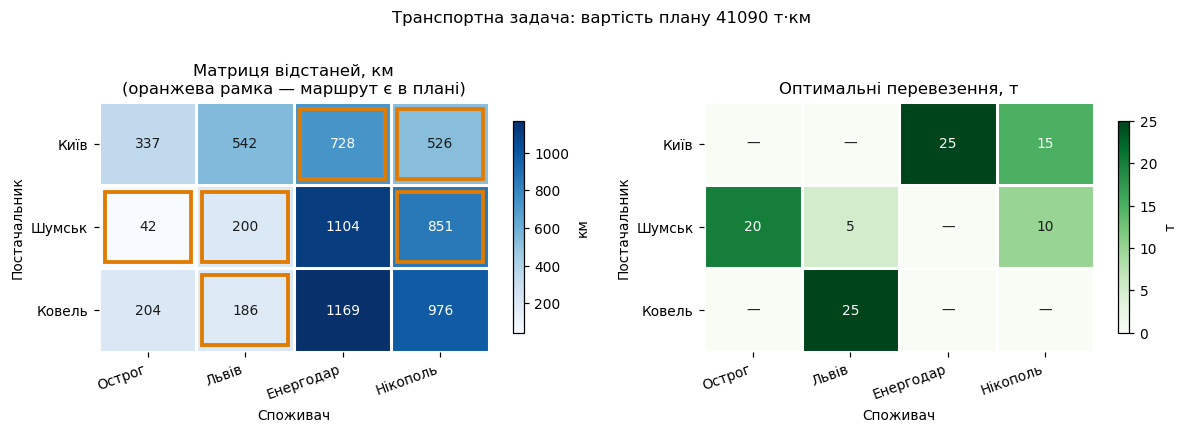

In [ ]:
fig, (ax_d, ax_x) = plt.subplots(1, 2, figsize=(11, 3.8))

def annotate_heatmap(ax, data, cmap, fmt, title, cbar_label, skip_zero=False):
    img = ax.imshow(data, cmap=cmap, aspect='auto')
    norm_vals = img.norm(data)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if skip_zero and data[i, j] <= tol_t:
                label = '—'
            else:
                label = fmt % data[i, j]
            ax.text(j, i, label, ha='center', va='center', fontsize=9,
                    color='white' if norm_vals[i, j] > 0.55 else '#1a1a1a')
    ax.set_xticks(range(n_con), споживачі, rotation=20, ha='right')
    ax.set_yticks(range(m_sup), постачальники)
    ax.set_xlabel('Споживач')
    ax.set_ylabel('Постачальник')
    ax.set_title(title)
    ax.set_xticks(np.arange(-.5, n_con), minor=True)
    ax.set_yticks(np.arange(-.5, m_sup), minor=True)
    ax.grid(which='minor', color='white', linewidth=2)
    ax.tick_params(which='minor', length=0)
    for side in ax.spines.values():
        side.set_visible(False)
    fig.colorbar(img, ax=ax, label=cbar_label, shrink=0.85)

annotate_heatmap(ax_d, D, 'Blues', '%.0f', 'Матриця відстаней, км\n(оранжева рамка — маршрут є в плані)', 'км')
annotate_heatmap(ax_x, t_plan, 'Greens', '%.0f', 'Оптимальні перевезення, т', 'т', skip_zero=True)

# виділити використані маршрути на карті відстаней
for i, j in zip(*np.nonzero(t_plan > tol_t)):
    ax_d.add_patch(plt.Rectangle((j - .44, i - .42), .88, .84, fill=False, ec='#e07b00', lw=2.5, zorder=5))

fig.suptitle('Транспортна задача: вартість плану %.0f' % cost_pulp, y=1.02)
plt.tight_layout()
plt.show()

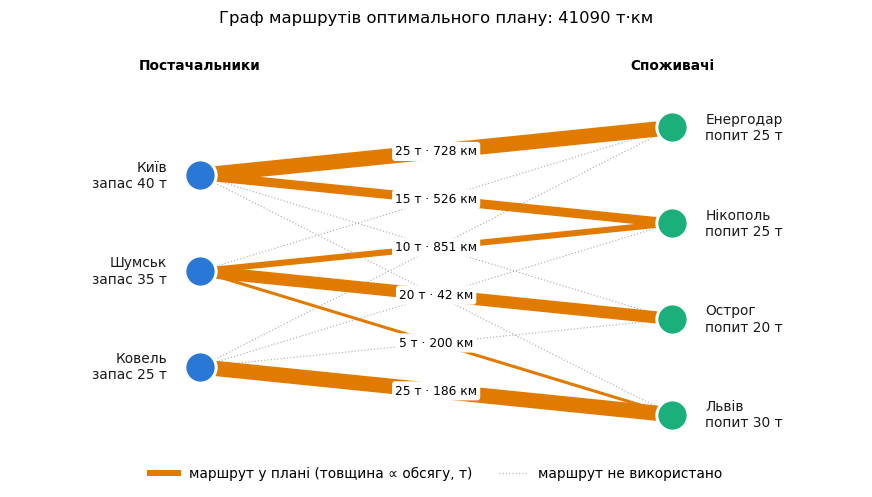

In [ ]:
import networkx as nx
from matplotlib.lines import Line2D

G = nx.DiGraph()
for i, s in enumerate(постачальники):
    G.add_node(s, side='sup', amount=запас[i])
for j, k in enumerate(споживачі):
    G.add_node(k, side='con', amount=попит[j])
for i, s in enumerate(постачальники):
    for j, k in enumerate(споживачі):
        G.add_edge(s, k, t=t_plan[i, j], km=D[i, j])

used_edges = [(u, v) for u, v, e in G.edges(data=True) if e['t'] > tol_t]
idle_edges = [(u, v) for u, v, e in G.edges(data=True) if e['t'] <= tol_t]

centre = (np.arange(m_sup)[:, None] * t_plan).sum(axis=0) / t_plan.sum(axis=0)
con_order = [споживачі[j] for j in np.argsort(centre, kind='stable')]
n_rows = max(m_sup, n_con)
pos = {s: (0, -(i + (n_rows - m_sup) / 2)) for i, s in enumerate(постачальники)}
pos.update({k: (1, -(j + (n_rows - n_con) / 2)) for j, k in enumerate(con_order)})

fig, ax = plt.subplots(figsize=(8, 4.6))
nx.draw_networkx_edges(G, pos, edgelist=idle_edges, ax=ax, arrows=False,
                       width=0.8, style=':', edge_color='#b5b5b5')
nx.draw_networkx_edges(G, pos, edgelist=used_edges, ax=ax, arrows=False,
                       width=[10 * G.edges[e]['t'] / t_plan.max() for e in used_edges],
                       edge_color='#e07b00')
nx.draw_networkx_edge_labels(G, pos, ax=ax, rotate=False, font_size=8,
                             edge_labels={e: '%.0f т · %.0f км' % (G.edges[e]['t'], G.edges[e]['km'])
                                          for e in used_edges},
                             bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none'))
for side, color in [('sup', '#2a78d6'), ('con', '#1baf7a')]:
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=420, node_color=color,
                           edgecolors='white', linewidths=2,
                           nodelist=[n for n, d in G.nodes(data=True) if d['side'] == side])

for n, d in G.nodes(data=True):
    x, y = pos[n]
    is_sup = d['side'] == 'sup'
    ax.text(x - .07 if is_sup else x + .07, y,
            '%s\n%s %d т' % (n, 'запас' if is_sup else 'попит', d['amount']),
            ha='right' if is_sup else 'left', va='center', color='#1a1a1a')
ax.text(0, .6, 'Постачальники', ha='center', fontweight='bold')
ax.text(1, .6, 'Споживачі', ha='center', fontweight='bold')

ax.legend(handles=[Line2D([], [], color='#e07b00', lw=4, label='маршрут у плані (товщина ∝ обсягу, т)'),
                   Line2D([], [], color='#b5b5b5', lw=0.8, ls=':', label='маршрут не використано')],
          loc='upper center', bbox_to_anchor=(.5, .02), ncol=2, frameon=False)
ax.set_xlim(-.4, 1.4)
ax.set_ylim(-(n_rows - .5), 1)
ax.axis('off')
ax.set_title('Граф маршрутів оптимального плану: %.0f' % cost_pulp)
plt.tight_layout()
plt.show()

**Висновок:** перевезення зосереджені на коротких для кожного споживача маршрутах. Острог і Львів отримують вантаж
із близьких Шумська й Ковеля (42–200 км), Енергодар і Нікополь — переважно з Києва (526–728 км), найближчого до півдня.
Дальні маршрути з Ковеля й Шумська на південь (851–1169 км) не використано, але Шумськ → Нікополь (851 км) довелося
задіяти на 10 т: запасу Києва (40 т) не вистачає на обидва південні міста (50 т).

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [23]:
ІНСТРУМЕНТИ_ШІ = 'Claude'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'ні',
    'етап 2, побудова моделі в Excel':      'ні',
    'етап 3, код на Python':                'ні',
    'етапи 4–5, читання та перевірка звіту': 'ні',
    'етап 6, рішення про закупівлю':        'код, перевірено',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = 'Перевірено код обчислень і побудови графіків, не знайдено помилок, але видалено деякі зайві частини (наприклад частини коду які не створюють жодної різниці або не потрібні у завданні)'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [24]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Кшик Олена Андріївна
інструменти:                               Claude
------------------------------------------------------------------------------
етап 1, формалізація моделі:               ні
етап 2, побудова моделі в Excel:           ні
етап 3, код на Python:                     ні
етапи 4–5, читання та перевірка звіту:     ні
етап 6, рішення про закупівлю:             код, перевірено
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
Перевірено код обчислень і побудови графіків, не знайдено помилок, але видалено деякі зайві частини (наприклад частини коду які не створюють жодної різниці або не потрібні у завданні)


---
# Крок 13. Фінальна самоперевірка

In [25]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
